# Arbres de décision et forêts aléatoires
## Jeu de données : Diabetes (Pima Indians)

---

### Contexte

Ce jeu de données est issu d'une étude menée sur des femmes d'origine Pima (peuple amérindien d'Arizona) âgées d'au moins 21 ans. L'objectif est de prédire, à partir de mesures médicales, si une patiente est **diabétique ou non**.

### Objectifs du TP

1. Charger et préparer les données
2. Entraîner un arbre de décision avec scikit-learn
3. Visualiser l'arbre et interpréter ses règles
4. Mettre en évidence le surapprentissage selon la profondeur de l'arbre de décision
5. Elaguage d'arbres CART (`ccp_alpha`)
7. Entraîner une forêt aléatoire et comparer avec un arbre de décision

---
## Partie 0 : imports et configuration

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

---
## Partie 1 : chargement et exploration des données

Le jeu de données contient les informations suivantes :

| Variable | Description |
|---|---|
| `Pregnancies` | Nombre de grossesses |
| `Glucose` | Concentration en glucose |
| `BloodPressure` | Pression artérielle |
| `SkinThickness` | Épaisseur du pli cutané du triceps |
| `Insulin` | Insuline sérique |
| `BMI` | Indice de masse corporelle |
| `DiabetesPedigreeFunction` | Fonction de pédigrée diabétique (hérédité) |
| `Age` | Âge en années |
| `Outcome` | Diabétique (1) ou non (0) |

**Exercice 1** : Chargez le fichier `diabetes.csv` dans un DataFrame `df`. Affichez ses dimensions, les premières lignes et les statistiques descriptives.

In [56]:
# Votre code ici
df = pd.read_csv("diabetes.csv")

In [57]:
# Statistiques descriptives
# Votre code ici
print(df.describe())



       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

**Question** : En observant les statistiques descriptives, identifiez les variables pour lesquelles une valeur minimale de 0 est **biologiquement impossible**. Justifiez pour chacune.

Comme le montrent les statistiques descriptives, les variables `Glucose`, `BloodPressure`, `SkinThickness` et `Insulin` ont des valeurs minimales de 0, ce qui est biologiquement impossible pour ces mesures. En effet, une concentration en glucose, une pression artérielle, une épaisseur du pli cutané ou une insuline sérique ne peuvent pas être nulles chez une personne vivante. Ces valeurs de 0 indiquent probablement des données manquantes ou des erreurs de saisie.

### 1.1 Détection et imputation des zéros aberrants

Certaines variables contiennent des zéros qui ne peuvent pas être des mesures réelles : une pression artérielle de 0, un IMC de 0 ou une concentration de glucose de 0 sont physiologiquement impossibles. Ces zéros sont en réalité des **valeurs manquantes déguisées**.

**Exercice 2** : Pour chaque variable identifiée, comptez le nombre de zéros et calculez le pourcentage qu'ils représentent. Remplacez-les ensuite par la **médiane de chaque variable**, **sauf** si le taux de valeurs manquantes vous semble trop élevé pour qu'une imputation soit raisonnable. Dans ce cas, justifiez votre choix et proposez une alternative.

In [58]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = {}
for col in cols_with_zeros:
    n_zeros = (df[col] == 0).sum()
    pct     = n_zeros / len(df) * 100
    zero_counts[col] = n_zeros
    print(f"{col:30s} : {n_zeros:3d} zéros ({pct:.1f}%)")

Glucose                        :   5 zéros (0.7%)
BloodPressure                  :  35 zéros (4.6%)
SkinThickness                  : 227 zéros (29.6%)
Insulin                        : 374 zéros (48.7%)
BMI                            :  11 zéros (1.4%)


In [59]:
# Remplacement des zéros par la médiane
df_clean = df.copy()
for col in cols_with_zeros:
        median = df_clean[col].median()
        df_clean[col] = df_clean[col].replace(0, median)
        
    

### 1.2 Visualisation

**Exercice 3** : Tracez la distribution de la variable cible `Outcome` et le taux de diabète selon des tranches d'âge (par exemple : <30, 30–45, >45).

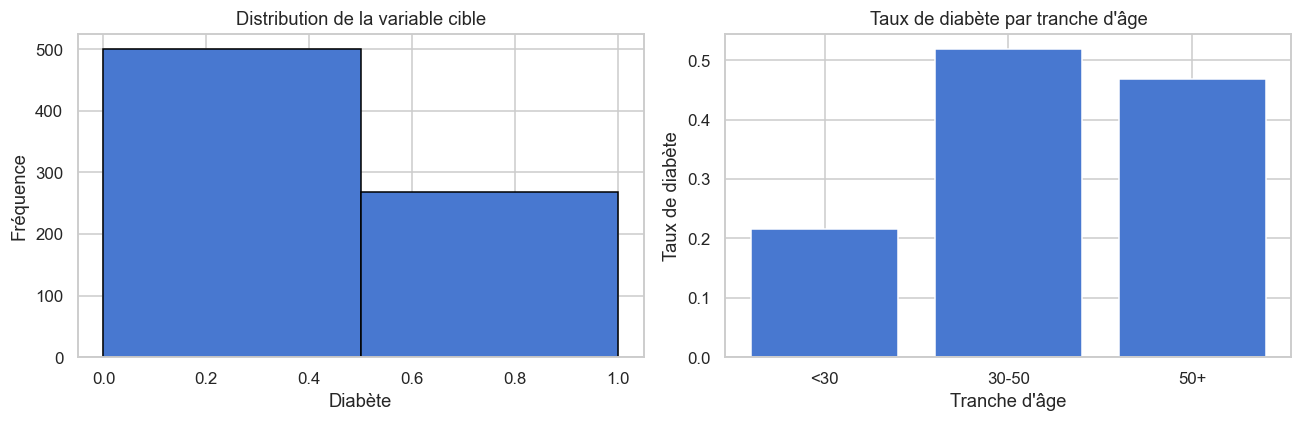

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution de la variable cible
# Votre code ici
axes[0].hist(df_clean['Outcome'], bins=2, edgecolor='black')
axes[0].set_xlabel('Diabète')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la variable cible')

# Taux de diabète par tranche d'âge
# Votre code ici
df_clean['Age_group'] = pd.cut(df_clean['Age'], bins=[0, 30, 50, 100], labels=['<30', '30-50', '50+'])
age_diabetes = df_clean.groupby('Age_group')['Outcome'].mean()
axes[1].bar(age_diabetes.index, age_diabetes.values)
axes[1].set_xlabel('Tranche d\'âge')
axes[1].set_ylabel('Taux de diabète')
axes[1].set_title('Taux de diabète par tranche d\'âge')

plt.tight_layout()
plt.show()

### 1.3 Préparation du jeu de données

**Exercice 4** 
- Sélectionner un sous-ensemble de variables pertinentes pour la prédiction
- Identifier la variable cible
- Séparer les données en ensembles d'entraînement et de test

In [94]:
features = ["Glucose", "BloodPressure", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
target = 'Outcome'

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Entraînement : {X_train.shape[0]} observations")
print(f"Test         : {X_test.shape[0]} observations")

Entraînement : 614 observations
Test         : 154 observations


---
## Partie 2 : arbre de décision avec scikit-learn

Nous allons maintenant utiliser l'implémentation CART de scikit-learn (`DecisionTreeClassifier`) pour entraîner et visualiser un arbre de décision.

### 2.1 Premier arbre

**Exercice 5** : Entraînez un arbre de décision avec une profondeur maximale de 3 (`max_depth=3`). Calculez son accuracy sur l'ensemble d'entraînement et sur l'ensemble de test

In [95]:
tree_d3 = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=SEED)
# Votre code ici
tree_d3.fit(X_train, y_train)
acc_train_d3  = tree_d3.score(X_train, y_train)
acc_test_d3  = tree_d3.score(X_test, y_test)
print(f"Accuracy entraînement : {acc_train_d3:.3f}")
print(f"Accuracy test         : {acc_test_d3:.3f}")

Accuracy entraînement : 0.767
Accuracy test         : 0.695


### 2.2 Visualisation de l'arbre

**Exercice 6** : Visualisez l'arbre entraîné en utilisant `plot_tree`. Passez les noms des variables (`feature_names`) et les noms des classes (`class_names=['Non diabétique', 'Diabétique']`).

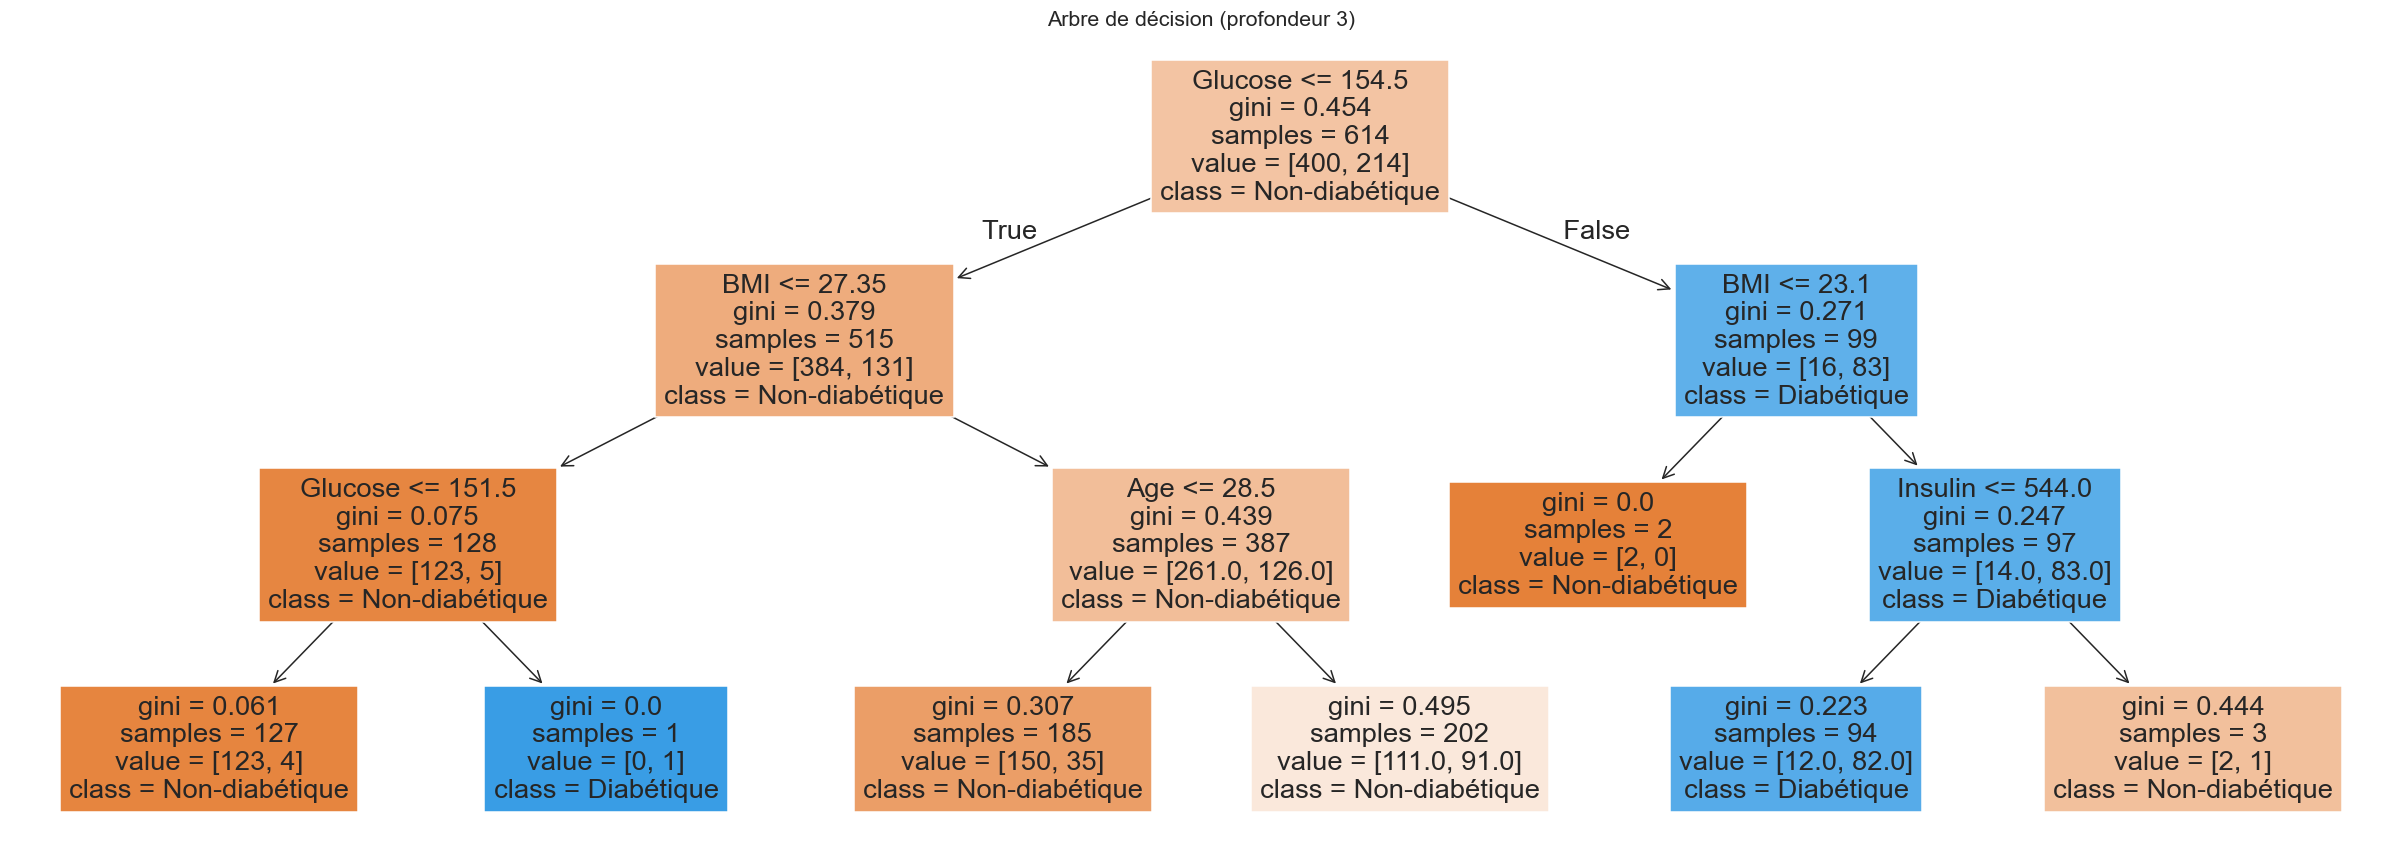

In [96]:
fig, ax = plt.subplots(figsize=(22, 8))
# Votre code ici
plot_tree(tree_d3, feature_names=features, class_names=['Non-diabétique', 'Diabétique'], filled=True, ax=ax)
plt.title("Arbre de décision (profondeur 3)", fontsize=14)
plt.tight_layout()
plt.show()

**Exercice 7** : Affichez également les règles de décision en texte à l'aide de `export_text`.

In [97]:
# Votre code ici
export_text(tree_d3, feature_names=features)


'|--- Glucose <= 154.50\n|   |--- BMI <= 27.35\n|   |   |--- Glucose <= 151.50\n|   |   |   |--- class: 0\n|   |   |--- Glucose >  151.50\n|   |   |   |--- class: 1\n|   |--- BMI >  27.35\n|   |   |--- Age <= 28.50\n|   |   |   |--- class: 0\n|   |   |--- Age >  28.50\n|   |   |   |--- class: 0\n|--- Glucose >  154.50\n|   |--- BMI <= 23.10\n|   |   |--- class: 0\n|   |--- BMI >  23.10\n|   |   |--- Insulin <= 544.00\n|   |   |   |--- class: 1\n|   |   |--- Insulin >  544.00\n|   |   |   |--- class: 0\n'

### 2.3 Matrice de confusion

**Exercice 8** : Affichez la matrice de confusion de l'arbre de profondeur 3 sur le jeu de test.

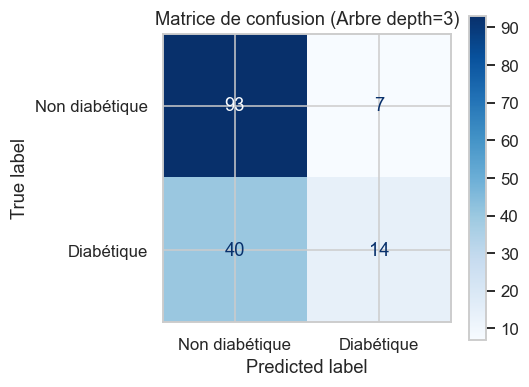

                precision    recall  f1-score   support

Non diabétique       0.70      0.93      0.80       100
    Diabétique       0.67      0.26      0.37        54

      accuracy                           0.69       154
     macro avg       0.68      0.59      0.59       154
  weighted avg       0.69      0.69      0.65       154



In [98]:
# CORRECTION
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    tree_d3, X_test, y_test,
    display_labels=['Non diabétique', 'Diabétique'],
    cmap='Blues', ax=ax
)
ax.set_title("Matrice de confusion (Arbre depth=3)")
plt.tight_layout()
plt.show()

print(classification_report(y_test, tree_d3.predict(X_test),
                             target_names=['Non diabétique', 'Diabétique']))

---
## Partie 3 : réglage des hyperparamètres

Les principaux hyperparamètres de CART dans scikit-learn sont :

| Paramètre | Rôle |
|---|---|
| `max_depth` | Profondeur maximale de l'arbre |
| `min_samples_split` | Nombre minimal d'observations pour diviser un nœud |
| `min_samples_leaf` | Nombre minimal d'observations dans une feuille |
| `max_leaf_nodes` | Nombre maximal de feuilles |

### 3.1 Effet de la profondeur et surapprentissage

Le surapprentissage se manifeste quand un modèle performe bien sur les données d'entraînement mais généralise mal sur de nouvelles données. Pour les arbres de décision, la profondeur est le principal levier : un arbre trop profond mémorise les données d'entraînement. Dans cette partie, nous allons visualiser cet effet.


**Exercice 9** : Pour des profondeurs allant de 1 à 20, entraînez un arbre et enregistrez l'accuracy sur l'entraînement et sur le test. Tracez ensuite les deux courbes sur un même graphique.

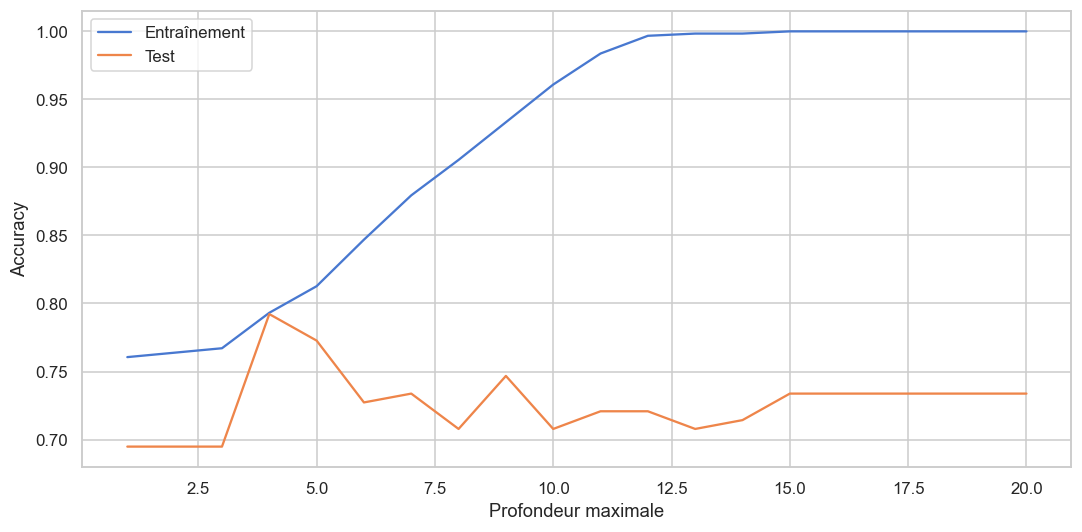

Meilleure profondeur (split simple) : 4


In [99]:
depths = range(1, 21)
acc_train_split = []
acc_test_split  = []

for d in depths:
    # Votre code ici
    # définir un modèle
    tree_split = DecisionTreeClassifier(max_depth=d, criterion='gini', random_state=SEED)
    # entraîner le modèle (.fit)
    tree_split.fit(X_train, y_train)
    # prédire sur l'ensemble train et calculer l'accuracy
    acc_train_split.append(tree_split.score(X_train, y_train))
    # prédire sur l'ensemble test et calculer l'accuracy
    acc_test_split.append(tree_split.score(X_test, y_test))
    pass

plt.figure(figsize=(10, 5))
# Votre code ici
plt.plot(depths, acc_train_split, label="Entraînement")
plt.plot(depths, acc_test_split, label="Test")

plt.xlabel("Profondeur maximale")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

best_depth_split = int(depths[np.argmax(acc_test_split)])
print(f"Meilleure profondeur (split simple) : {best_depth_split}")

**Question** : À partir de quelle profondeur observe-t-on clairement le surapprentissage ? Comment se manifeste-t-il sur le graphique ? Quelle profondeur vous semble être un bon compromis ?


La profondeur où début le surapprentissage sur le graphique est autour de 10. On voit sur le graphique que l'accuracy sur l'entraînement continue d'augmenter avec la profondeur, tandis que l'accuracy sur le test commence à staagner. Un bon compromis semble être une profondeur de 5 à 7, où l'accuracy sur le test est encore élevée et proche de celle de l'entraînement.

### 3.2 Effet de `min_samples_leaf`

**Exercice 10** : Fixez `max_depth` à la valeur optimale trouvée. Faites varier `min_samples_leaf` de 1 à 50 et tracez l'accuracy en fonction de ce paramètre.

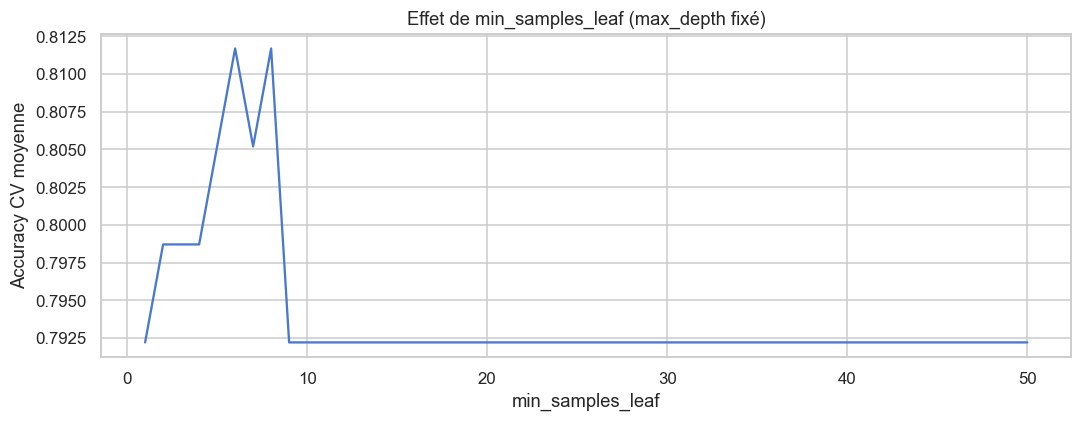

Meilleur min_samples_leaf : 6


In [100]:
leaf_sizes = range(1, 51)
acc_leaf = []

for msl in leaf_sizes:
    tree = DecisionTreeClassifier(
        max_depth=best_depth_split,
        min_samples_leaf=msl,
        criterion='gini',
        random_state=SEED
    )
    # Votre code ici
    # entraîner le modèle (.fit)
    tree.fit(X_train, y_train)
    # prédire sur l'ensemble test et calculer l'accuracy
    acc_leaf.append(tree.score(X_test, y_test))

plt.figure(figsize=(10, 4))
# Votre code ici
plt.plot(leaf_sizes, acc_leaf)

plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy CV moyenne")
plt.title("Effet de min_samples_leaf (max_depth fixé)")
plt.tight_layout()
plt.show()

best_msl = int(leaf_sizes[np.argmax(acc_leaf)])
print(f"Meilleur min_samples_leaf : {best_msl}")

**Exercice 11** : Entraînez un arbre avec les meilleurs hyperparamètres trouvés (`best_depth_split` et `best_msl`). Calculez son accuracy sur le test et affichez sa matrice de confusion.

In [101]:
tree_prelag = DecisionTreeClassifier(
    max_depth=best_depth_split,
    min_samples_leaf=best_msl,
    criterion='gini',
    random_state=SEED
)
# Votre code ici
tree_prelag.fit(X_train, y_train)

acc_train_prelag = tree_prelag.score(X_train, y_train)
acc_test_prelag  = tree_prelag.score(X_test, y_test)
print(f" Accuracy train : {acc_train_prelag:.3f} | test : {acc_test_prelag:.3f}")

 Accuracy train : 0.785 | test : 0.812


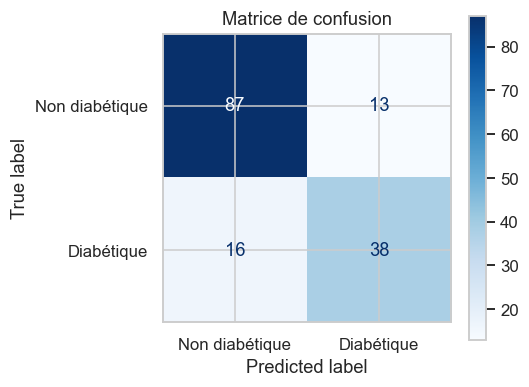

In [102]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    tree_prelag, X_test, y_test,
    display_labels=['Non diabétique', 'Diabétique'],
    cmap='Blues', ax=ax
)
ax.set_title("Matrice de confusion")
plt.tight_layout()
plt.show()

---
## Partie 4 : élagage CART (`ccp_alpha`)

L'élagage par complexité-coût consiste à construire d'abord l'arbre complet, puis à le simplifier en remontant. À chaque étape, on supprime le sous-arbre qui dégrade le moins les performances pondérées par sa complexité.

Le critère minimisé est :
$$C_\alpha(T) = R(T) + \alpha \cdot |T|$$

où $R(T)$ est le coût de mauvais classement dans $T$,  $|T|$ est le nombre de feuilles et $\alpha \geq 0$ est le paramètre de régularisation :
- $\alpha = 0$ : aucun élagage (arbre complet)
- $\alpha$ grand : arbre fortement élagué (peu de feuilles)

scikit-learn implémente cela via `ccp_alpha` dans `DecisionTreeClassifier`.

### 4.1 Chemin d'élagage

La méthode `cost_complexity_pruning_path()` calcule la séquence des valeurs de $\alpha$ et des impuretés correspondantes lors de l'élagage progressif de l'arbre complet.

**Exercice 12** : Calculez le chemin d'élagage sur les données d'entraînement. Tracez l'évolution du nombre de feuilles en fonction de `ccp_alpha`.

Nombre de valeurs d'alpha : 59
Alpha min : 0.000000
Alpha max : 0.025721


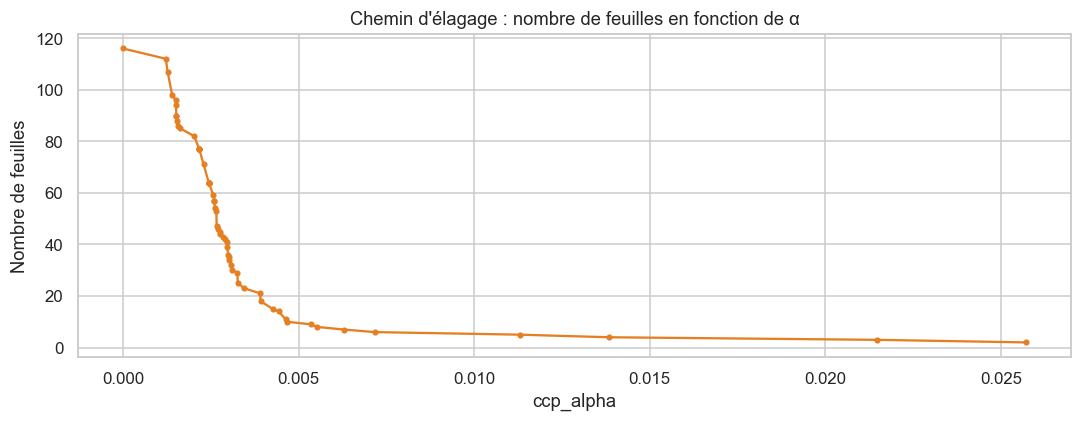

In [103]:
# CORRECTION
tree_full = DecisionTreeClassifier(random_state=SEED)
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]
impurities = path.impurities[:-1]

print(f"Nombre de valeurs d'alpha : {len(ccp_alphas)}")
print(f"Alpha min : {ccp_alphas.min():.6f}")
print(f"Alpha max : {ccp_alphas.max():.6f}")

# Nombre de feuilles pour chaque alpha
n_leaves = []
for alpha in ccp_alphas:
    t = DecisionTreeClassifier(ccp_alpha=alpha, random_state=SEED)
    t.fit(X_train, y_train)
    n_leaves.append(t.get_n_leaves())

plt.figure(figsize=(10, 4))
plt.plot(ccp_alphas, n_leaves, marker='.', color='#e67e22')
plt.xlabel("ccp_alpha")
plt.ylabel("Nombre de feuilles")
plt.title("Chemin d'élagage : nombre de feuilles en fonction de α")
plt.tight_layout()
plt.show()

**Question** : Que se passe-t-il quand `ccp_alpha` augmente ? Faites le lien avec la formule $C_\alpha(T) = R(T) + \alpha \cdot |T|$.

Quand `ccp_alpha` augmente, le terme de pénalité $\alpha \cdot |T|$ devient plus important dans la fonction de coût $C_\alpha(T)$. Par conséquent, l'algorithme privilégie des arbres avec moins de feuilles pour minimiser ce coût. Cela se traduit par une diminution du nombre de feuilles à mesure que `ccp_alpha` augmente, ce qui correspond à un élagage plus agressif de l'arbre.

### 4.2 Sélection du meilleur alpha

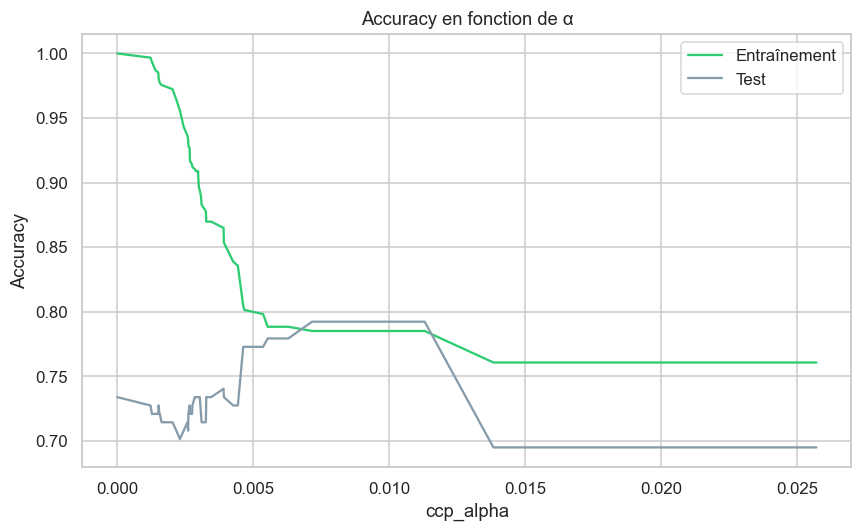

Meilleur ccp_alpha     : 0.007165
Accuracy test associée : 0.792


In [104]:
# CORRECTION
acc_test_alpha  = []
acc_train_alpha = []

for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(ccp_alpha=alpha, random_state=SEED)
    tree.fit(X_train, y_train)
    acc_train_alpha.append(accuracy_score(y_train, tree.predict(X_train)))
    acc_test_alpha.append(accuracy_score(y_test,  tree.predict(X_test)))

acc_test_alpha  = np.array(acc_test_alpha)
acc_train_alpha = np.array(acc_train_alpha)

plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, acc_train_alpha, label='Entraînement', color='#2ecc71')
plt.plot(ccp_alphas, acc_test_alpha,  label='Test',         color='#879caa')
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy en fonction de α")
plt.legend()
plt.tight_layout()
plt.show()

best_alpha = ccp_alphas[np.argmax(acc_test_alpha)]
print(f"Meilleur ccp_alpha     : {best_alpha:.6f}")
print(f"Accuracy test associée : {acc_test_alpha.max():.3f}")

**Question** : Comparez l'arbre élaguée avec l'arbre de la partie 3. Lequel est le plus simple ? Lequel performe le mieux sur le test ?

In [108]:
# CORRECTION
tree_postlag = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=SEED)
tree_postlag.fit(X_train, y_train)

acc_train_postlag = accuracy_score(y_train, tree_postlag.predict(X_train))
acc_test_postlag  = accuracy_score(y_test,  tree_postlag.predict(X_test))

print(f"Elagage Profondeur : {tree_postlag.get_depth()} | Feuilles : {tree_postlag.get_n_leaves()}")
print(f"Accuracy train : {acc_train_postlag:.3f} | test : {acc_test_postlag:.3f}")

Elagage Profondeur : 4 | Feuilles : 6
Accuracy train : 0.785 | test : 0.792


*Votre réponse ici*

---
## Partie 5 : forêt aléatoire

La forêt aléatoire combine plusieurs arbres de décision entraînés sur des jeux bootstrappés, en limitant à chaque nœud le nombre de variables candidates. Elle corrige les deux principaux défauts de l'arbre seul : la variance élevée et l'instabilité.

### 5.1 Entraînement de la forêt

**Exercice 13** : Entraînez une forêt aléatoire avec 200 arbres (`n_estimators=200`) et activez le calcul de l'erreur OOB (`oob_score=True`). Calculez l'accuracy sur le test et comparez avec le meilleur arbre de la Partie 4.

In [114]:
rf = RandomForestClassifier(
    n_estimators=20000,
    oob_score=True,
    random_state=SEED
)

# Votre code ici
rf.fit(X_train, y_train)

acc_train_rf = rf.score(X_train, y_train)
acc_test_rf = rf.score(X_test, y_test)

print(f"Accuracy entraînement (forêt) : {acc_train_rf:.3f}")
print(f"Accuracy test (forêt, 200 arbres) : {acc_test_rf:.3f}")
print(f"Erreur OOB                         : {1 - rf.oob_score_:.3f}")
print(f"Score OOB                          : {rf.oob_score_:.3f}")

Accuracy entraînement (forêt) : 1.000
Accuracy test (forêt, 200 arbres) : 0.779
Erreur OOB                         : 0.241
Score OOB                          : 0.759


**Question** : Comparez l'accuracy test de la forêt avec celle du meilleur arbre individuel. La forêt améliore-t-elle les performances ? Le score OOB est-il proche de l'accuracy test ?



### 5.2 Erreur OOB en fonction du nombre d'arbres

L'erreur OOB est estimée sans jeu de validation séparé : chaque observation est évaluée uniquement par les arbres qui ne l'ont pas vue pendant l'entraînement. Elle converge à mesure qu'on ajoute des arbres.

**Exercice 14** : Tracez l'évolution de l'erreur OOB cumulée en fonction du nombre d'arbres.

**Indication** : utilisez `warm_start=True` et augmentez progressivement `n_estimators` dans une boucle, ou exploitez l'attribut `estimators_` de la forêt déjà entraînée.

---
## Partie 6 : bilan comparatif

In [107]:
# Arbre complet (sans contrainte)
tree_full_fit = DecisionTreeClassifier(random_state=SEED)
tree_full_fit.fit(X_train, y_train)
acc_train_full = accuracy_score(y_train, tree_full_fit.predict(X_train))
acc_test_full  = accuracy_score(y_test,  tree_full_fit.predict(X_test))

results = {
    'Modèle': [
        'Arbre complet (sans contrainte)',
        'Arbre depth=3',
        f'Tuning hyperparamètres (depth={best_depth_split}, msl={best_msl})',
        f'Elagage (α={best_alpha:.5f})'
    ],
    'Profondeur': [
        tree_full_fit.get_depth(),
        3,
        tree_prelag.get_depth(),
        tree_postlag.get_depth()
    ],
    'Nb feuilles': [
        tree_full_fit.get_n_leaves(),
        tree_d3.get_n_leaves(),
        tree_prelag.get_n_leaves(),
        tree_postlag.get_n_leaves()
    ],
    'Accuracy Train': [
        round(acc_train_full, 3),
        round(acc_train_d3, 3),
        round(acc_train_prelag, 3),
        round(acc_train_postlag, 3)
    ],
    'Accuracy Test': [
        round(acc_test_full, 3),
        round(acc_test_d3, 3),
        round(acc_test_prelag, 3),
        round(acc_test_postlag, 3)
    ]
}

df_results = pd.DataFrame(results)
df_results['Écart Train-Test'] = (df_results['Accuracy Train'] - df_results['Accuracy Test']).round(3)
df_results

,Modèle,Profondeur,Nb feuilles,Accuracy Train,Accuracy Test,Écart Train-Test
0,Arbre complet (sans contrainte),15,116,1.000,0.734,0.266
1,Arbre depth=3,3,7,0.767,0.695,0.072
2,"Tuning hyperparamètres (depth=4, msl=6)",4,14,0.785,0.812,-0.027
3,Elagage (α=0.00717),4,6,0.785,0.792,-0.007
